In [42]:
import os

from dotenv import load_dotenv

load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("GOOGLE_API_KEY is set")
else:
    raise ValueError("GOOGLE_API_KEY is not set")

GOOGLE_API_KEY is set


In [43]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

## pydantic schema


In [44]:
from pydantic import BaseModel,Field

class graph_Schema(BaseModel):
    topic: str = Field(..., description="Topic of the graph")
    post: str = Field(..., description="linkedin post content")
    currated_post: str = Field(..., description="curated linkedin post content")


demo_obj = graph_Schema(
    topic="the importance of data privacy",
    post="data privacy is important",
    currated_post="data privacy is important",
)

print(demo_obj)

topic='the importance of data privacy' post='data privacy is important' currated_post='data privacy is important'


In [45]:
def create_post(state: graph_Schema)->graph_Schema:

    #convert the model into dict
    state=state.model_dump()

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"write a linkedin post about {topic}")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["post"] = post

    return state
    





def currate_post(state: graph_Schema)->graph_Schema:

    #convert the model into dict
    state=state.model_dump()


    #extract the post from the state
    post = state["post"]

    #passing the post to llm  to generate a currate linkedin post
    currated_post = model.invoke(f"currate the following linkedin post with the genz tone: {post}")
    currated_post = currated_post.content[0]["text"]

    #updating the post with genrated post
    state["currated_post"] = currated_post

    return state

    #updating the post with updated post



In [46]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(
    graph_Schema)

graph.add_node("create post",create_post)
graph.add_node("currate post",currate_post)

graph.add_edge(START,"create post")
graph.add_edge("create post","currate post")
graph.add_edge("currate post",END)


pydantic_graph = graph.compile()

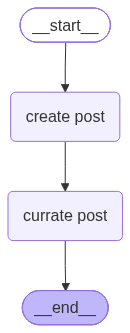

In [47]:
from IPython.display import display,Image

#you could see the error with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [48]:
pydantic_graph.invoke(
    {"topic":"the importance of data privacy in the digital age",
     "post":"",
     "currated_post":""}
)

{'topic': 'the importance of data privacy in the digital age',
 'post': 'Here is a drafted LinkedIn post designed for high engagement, readability, and impact:\n\n***\n\n"Data is the new oil." \n\nWe’ve all heard the phrase. But here is the part we often forget: **Oil leaks cause disasters.** 🛢️💥\n\nIn an era defined by generative AI, hyper-connectivity, and cloud computing, the volume of personal data generated every second is staggering. But as our digital footprints expand, so does the risk.\n\nData privacy is no longer just a hurdle for the legal team or an IT checkbox. It is a **core business imperative** and a **fundamental human right**. \n\nHere’s why prioritizing data privacy matters more today than ever before:\n\n🔹 **Trust is the Ultimate Currency**\nIn a crowded market, trust is your biggest differentiator. Customers are increasingly conscious of how their information is used. If they don\'t trust you with their data, they won\'t trust you with their business.\n\n🔹 **Privac